<a href="https://colab.research.google.com/github/jrhumberto/2026-mestrado-pep/blob/main/capes_scielo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Busca Bibliográfica
 Programa implemntado por Humberto Bezerra em 29/03/2026 - Ver: https://rede-lattes.org/ , https://rafaelantunes123-delineia.hf.space/

In [ ]:
############## BIBLIOTECAS #####################################################


# Instalar pacman se ainda não estiver instalado
if (!require("pacman")) install.packages("pacman")

# Carregar todos os pacotes necessários com pacman
pacman::p_load(
  stringr, # Manipulação de strings
  dplyr,   # Manipulação de dados
  writexl, # Exportar para Excel
  ggplot2, # Visualização de dados
  easyScieloPack, # Busca de artigos no Scielo
  capesR,  # Busca de Teses e dissertações na CAPES
  bibliometrix, # Analise bibliometrica
  tidyverse,
  wordcloud2,
  gutenbergr,
  tm
  ggtext,  # Textos ricos em gráficos
  ggpubr,  # Publicação de gráficos bonitos
  ggrepel, # Evita sobreposição de labels
  arrow,   # Leitura e escrita de dados em formato Parquet
  purrr    # Programação funcional (map, walk, etc.)
)

remotes::install_github("hugoavmedeiros/capesR", force = TRUE)

## Busca Capes Antiga (busca no titulo e no resumo)

Fonte complementar: https://gist.github.com/jrhumberto/bdbfe1323588065de7eea31d9348521d

In [ ]:


# Carrega os pacotes necessários
library(capesR)
library(dplyr)

# Define os anos desejados
anos <- 2021:2026  # Ajustado para os anos disponíveis

# Define o diretório persistente onde os dados serão salvos
diretorio_dados <- "dados_capes"

# Baixa os arquivos do repositório da CAPES/OSF
arquivos_capes <- download_capes_data(
  years = anos,
  destination = diretorio_dados
)

# Transforma a lista nomeada em vetor simples de caminhos
arquivos_parquet <- unlist(arquivos_capes)

# Lê os dados completos
dados_completos <- read_capes_data(arquivos_parquet)

# Busca por trabalhos que mencionam "telegram" nos campos 'titulo' e 'resumo'
resultado <- bind_rows(
  search_capes_text(dados_completos, term = c("controle interno", "setor publico"), field = "titulo"),
  search_capes_text(dados_completos, term = c("controle interno","setor publico"), field = "resumo")
) %>%
  distinct()  # Remove duplicações

# Visualiza os resultados
glimpse(resultado)

resultado <- resultado %>%
  group_by(autoria) %>%
  filter(n() == 1) %>%
  ungroup() %>%
  distinct()


# Opcional: salva em CSV
getwd()
write.csv(resultado, "resultado.csv", row.names = FALSE)

## Busca CAPES

Fonte: https://www.youtube.com/watch?v=KtNPqDhUOsQ

Referência: https://hugoavmedeiros.github.io/capesR/reference/search_capes_text.html

In [ ]:
library(capesR)
library(dplyr)

# Baixar dados entre 1987 e 2022
capes <- download_capes_data(c(2021:2026))

df_capes <- map_dfr(capes,read_parquet)

df_capes$titulo_min <- tolower(df_capes$titulo) # colocar tudo em letra minuscula

# df_capes$tema <- stringr::str_detect(
#   df_capes$titulo_min,
#   "\\bguerra\\b|
#    \\bguerras\\b|
#    \\bwar\\b|
#    \\bwars\\b|
#    \\bguerra civil\\b|
#    \\bcivil war\\b|
#    \\bguerra mundial\\b|
#    \\bworld war\\b|
#    \\bguerra fria\\b|
#    \\bcold war\\b|
#    \\bconflicto armado\\b|
#    \\barmed conflict\\b"
# )

df_capes$tema <- stringr::str_detect(
  df_capes$titulo_min,
  "\\bcontrole interno\\b"
)


df_tematica_capes <- df_capes %>%
  filter(tema == "TRUE") %>%
  arrange(ano_base) %>%
  dplyr::select(-tema) # verifica se tem ou nao

# Salvar os resultados filtrados em novo arquivo
write_xlsx(df_tematica_capes, "controle_interno.xlsx")

# getwd()
write.csv(df_tematica_capes, 'controle_interno.csv', row.names=FALSE)


File already exists: /tmp/RtmpkS91wE/capes_2021.parquet

File already exists: /tmp/RtmpkS91wE/capes_2022.parquet

Downloading: /tmp/RtmpkS91wE/capes_2023.parquet

Downloading: /tmp/RtmpkS91wE/capes_2024.parquet



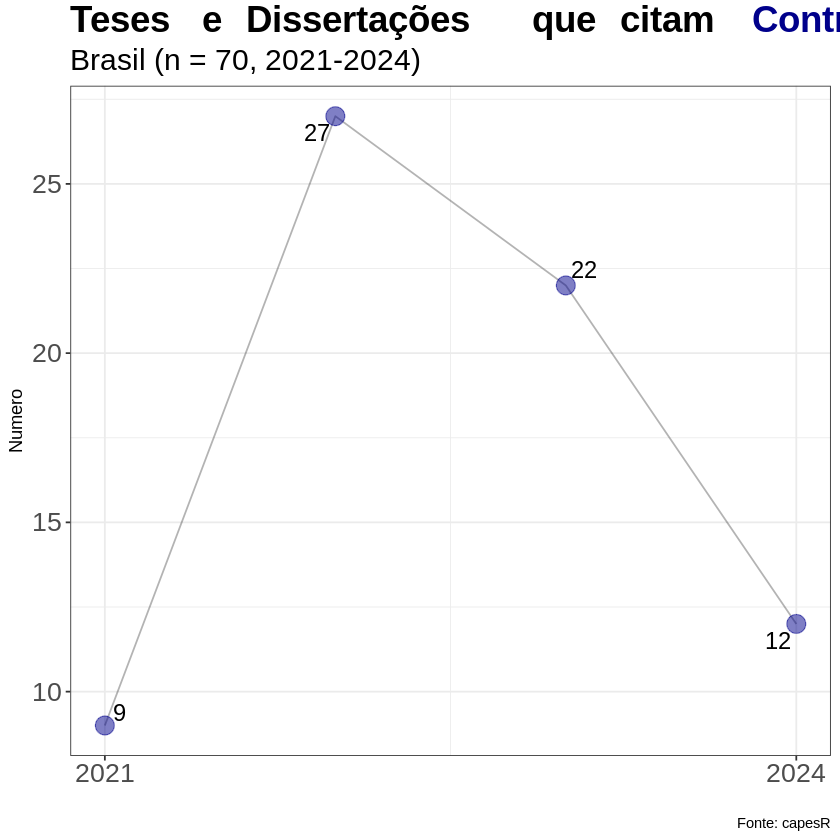

In [ ]:
## Gráficos

df_agg_ano_capes <- df_tematica_capes %>%
  group_by(ano_base) %>%
  summarise(n_casos = n())

total_n_casos <- sum(df_agg_ano_capes$n_casos)


df_agg_ano_capes %>%
  ggplot(aes(ano_base, n_casos)) +
  geom_line(alpha =.3) +
  geom_point(size = 5, alpha = .5, col ="darkblue") +
  geom_text_repel(aes(label = n_casos), size = 5) +
  scale_x_continuous(
    breaks = seq(
      min(df_agg_ano_capes$ano_base, na.rm = TRUE),
      max(df_agg_ano_capes$ano_base, na.rm = TRUE),
      by = 3
    )
  )+
labs(
   x = "",
   y = "Numero",
   title = "Teses e Dissertações que citam<b><span style='color:darkblue;'> Controle Interno </span></b> no titulo",
   subtitle = paste0("Brasil (n = ", total_n_casos, ", 2021-2024)"),
   caption = "Fonte: capesR"
)+
theme_bw() +
theme(
  plot.title = element_markdown()
) +
theme(
  plot.title = element_markdown(size = 22, face ="bold"),
  plot.subtitle = element_text(size= 18),
 axis.text = element_text(size = 16)
)

In [ ]:
ggsave("controle_interno.png", width = 12, height = 8, dpi = 300)

## Busca Scielo

>Fonte: https://www.youtube.com/watch?v=iBmMt19E6OQ

In [ ]:
library("easyScieloPack")
base_scielo <- search_scielo("Controle Interno", n_max = 100000)

Warning message in fetch_scielo_results(query_obj):
“No articles found on page. Retrying with a different User-Agent...”


In [ ]:
View(base_scielo)

title,authors,year,doi,abstract
<chr>,<chr>,<chr>,<chr>,<chr>
Relación entre atribuciones causales y rendimiento académico: revisión sistemática siguiendo criterios PRISMA,"Vera-Sagredo, Angélica; Contreras-González, Juan Pablo; Chiappe, Andrés",2026,https://doi.org/10.22235/pe.v19i1.4814,"Abstract: Academic performance is influenced by psychosocial and motivational factors, among which causal attributions are central to understanding how students explain successes and failures. This systematic review examined the relationship between causal attributions and academic performance, taking into account mediating and moderating variables, as well as different educational levels. The study was conducted following PRISMA guidelines, with searches in Web of Science (n = 183), Scopus (n = 208), and SciELO (n = 40), yielding 431 records. After removing duplicates and applying selection criteria using Rayyan, 27 studies including 17,752 participants, across primary to higher education levels, were retained. Results indicate that an internal locus of control and attributions focused on effort and ability are associated with higher performance, motivation, self-efficacy, and resilience, whereas external attributions-such as luck, task difficulty, or others’ responsibility-are linked to lower performance and an increased risk of school dropout. Gender differences were observed: women exhibited greater internal control and resilience, while men attributed their achievements primarily to effort and teaching quality. Additionally, mediating variables such as self-efficacy, academic self-concept, resilience, and self-regulation strategies, and moderating variables such as gender, age, mode of study, and contexts of vulnerability, significantly influence this relationship. In conclusion, the findings highlight the need to promote psychoeducational interventions that foster internal and adaptive attributional styles, particularly for students in vulnerable situations or with special educational needs"
"Análisis de la calidad y su impacto económico: evaluación del contenido de lípidos, sodio y nitritos en productos cárnicos","Benavente Bevilacqua, Carlos Manuel; Guerrero Salazar, Fernando Alberto Eugenio; Leveau Bartra, Harry Raul; Calle Vilca, Luis Alejandro; Cuba Córdova, Zoila Magaly",2025,https://doi.org/10.59659/impulso.v.5i12.216,"ABSTRACT Quality management in the food industry is a determining factor for business competitiveness and public health. This study analyses the quality of meat products sold in Ica, Peru, based on the verification of lipid, sodium and nitrite levels, with the aim of assessing the administrative implications of compliance or non-compliance with Peruvian Technical Standards, particularly with regard to process management, internal control and strategic decision-making in companies in the meat sector. Twenty meat product samples were randomly collected to analyse their lipid, sodium and nitrite content. The results revealed that 10% of the samples exceeded the lipid limit, 5% exceeded the sodium limit and 5% exceeded the nitrite limit. These findings not only pose a risk to consumer health, but also generate significant non-compliance costs for producers, including potential penalties, loss of reputation, and barriers to access more demanding markets. It is concluded that the implementation of quality management systems and rigorous control of the supply chain are strategic investments that mitigate financial risks and strengthen business sustainability."
La cultura ética en las organizaciones mexicanas: el papel mediador de la conciencia moral,"García-Leal, Hilda; Mendoza-Gómez, Joel",2025,https://doi.org/10.18046/j.estger.2025.176.7462,"Abstract Ethical culture in today's business environment represents a competitive advantage, and due to the growth of the retail sector in Mexican organizations, it is important to study it academically. The objective was to empirically verify a mediating conceptual model: moral co

In [ ]:
names(base_scielo)

[1] "title"    "authors"  "year"     "doi"      "abstract"

In [ ]:
base_scielo <- base_scielo %>%
  mutate(
    titulo_min = tolower(title) ,
    tema = stringr::str_detect(
             titulo_min,
            "\\bcontrole interno\\b"
    ),
    ano_base = year
  )

df_tematica_scielo <- base_scielo %>%
  filter(tema == "TRUE") %>%
  arrange(ano_base) %>%
  dplyr::select(-tema) # verifica se tem ou nao

# Salvar os resultados filtrados em novo arquivo
write_xlsx(df_tematica_scielo, "controle_interno_scielo_100mil.xlsx")

write.csv(df_tematica_scielo, 'controle_interno_scielo_100mil.csv', row.names=FALSE)

In [ ]:
library(wordcloud2)


scielo_corpus <- VCorpus(VectorSource(df_tematica_scielo$title))
scielo_corpus <- scielo_corpus %>%
  tm_map(removeNumbers) %>%
  tm_map(removePunctuation) %>%
  tm_map(content_transformer(tolower)) %>%
  tm_map(
  removeWords,
  c(
    stopwords("english"),
    stopwords("spanish"),
    stopwords("portuguese"),
    "one" # extra, se quiser manter
  )
)

tdm <- TermDocumentMatrix(scielo_corpus) %>% as.matrix() # transforma em amtriz

palavras <- sort(rowSums(tdm), decreasing = T) # Orderna a frequencia

df <- data.frame(palavra = names(palavras), freq = palavras)


df$peso <- df$freq/sum(df$freq)*100 # Peso relativo de cada palvavra dentro do documento
df$peso <- round(df$peso, 2) # para arredondar

# Nuvem não funciona em Google Colab
my_cloud <- wordcloud2(df, size = 1,
                shape = "oval",
                rotateRatio = .7,
               ellipticity = .7,
               color = "#990012") # Use 'df' instead of 'demoFreq'


my_cloud


# Trecho Abaixo funciona em Google Colab

# install.packages("ggwordcloud")
# library(ggwordcloud)
# library(ggplot2)

# ggplot(df, aes(label = palavra, size = freq)) +
#   geom_text_wordcloud(size=5) +
#   theme_minimal()


## Busca Scholar

Fonte: https://www.youtube.com/watch?v=4AZZXT8XNUg

Complemento: https://www.rdocumentation.org/packages/scholar/versions/0.2.6

In [ ]:
## https://github.com/jkeirstead/scholar
## https://cran.r-project.org/web/packages/scholar/index.html
## https://www.andreashandel.com/posts/2020-02-01-publications-analysis-1/
# https://scholar.google.com/citations?user=5sz_jBoAAAAJ&hl=en -> Perfil do Gary King

library(ggplot2)
library(scholar) # esse comando chama o pacote para o ambiente do R

data_scholar <- get_coauthors('5sz_jBoAAAAJ&hl') # Puxa os dados da internet

# Nivel 1
plot_coauthors(data_scholar)

#Nivel 2
plot_coauthors(data_scholar) +
  labs(title = "Rede de coautoria de Gary King",
  subtitle = "Dados atualizados em 11 de março de 2026",
  caption = "Fonte: elaboracao propria a partir do pacote scholar")


# Nivel 3
plot_coauthors(data_scholar) +
labs(title = "Rede de coautoria de Gary King",
subtitle = "Dados atualizados em 11 de março de 2026",
caption = "Fonte: elaboracao propria a partir do pacote scholar") +
theme_void(base_size = 20) +
theme(
  plot.title = element_text(size = 36, face = "bold"),
  plot.subtiltle = element_text(size = 24),
  plot.caption = element_text(size= 16),
  plot.title.position = "plot"
)

# Nivel 4

nome <- data_scholar$author

plot_coauthors(data_scholar) +
labs(
  title = paste("Rede de coautoria de", nome),
  subtitle = paste("Atualizado em", format(Sys.Date(), "%d de %B de %Y")),
  caption = "Fonte: elaboracao propria a partir do Google Scholar"
)+
theme_void(base_size = 20) +
theme(
  plot.title = element_text(size = 36, face = "bold"),
  plot.subtiltle = element_text(size = 24),
  plot.caption = element_text(size= 16),
  plot.title.position = "plot"
)







In [ ]:
install.packages("scholar")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘tweenr’, ‘polyclip’, ‘gridExtra’, ‘RcppArmadillo’, ‘R.methodsS3’, ‘R.oo’, ‘R.utils’, ‘igraph’, ‘ggforce’, ‘ggrepel’, ‘viridis’, ‘graphlayouts’, ‘R.cache’, ‘tidygraph’, ‘ggraph’




In [ ]:
library(scholar)
### Exemplos ###

# Define the id for Richard Feynman
id <- 'B7vSqZsAAAAJ'

# Get his profile and print his name
l <- get_profile(id)
l$name



Warning message in get_scholar_resp(url, attempts_left - 1):
“Cannot connect to Google Scholar. Is the ID you provided correct?”


ERROR: Error in l$name: $ operator is invalid for atomic vectors


In [ ]:
# Get his citation history, i.e. citations to his work in a given year
get_citation_history(id)

# Get his publications (a large data frame)
get_publications(id)

x <- 'Ux9W94sAAAAJ'
#coauthor_network <- get_coauthors('KVNSqBOAAAAJ')

coauthor_network <- get_coauthors(id)
nome <- coauthor_network$author

plot_coauthors(coauthor_network) +
labs(
  title = paste("Rede de coautoria de", nome),
  subtitle = paste("Atualizado em", format(Sys.Date(), "%d de %B de %Y")),
  caption = "Fonte: elaboracao propria a partir do Google Scholar"
)+
theme_void() + # base limpa
theme(
plot.title = element_text(size = 30, face = "bold", hjust = 0.5),
plot.subtitle = element_text(size = 20, hjust = 0.5),
plot.caption = element_text(size = 16, hjust = 0.5)
)

## Busca Bibliometrix

- **Bibliometria com o uso do R e Bibliometrix**: https://www.youtube.com/watch?v=pqZJGY0mXpw
- **Mini-curso: Bibliometria na prática com R e Bibliometrix (Clayton Martins Pereira) - 2022**: https://www.youtube.com/watch?v=2XKsq_y9z_M

- **Bibliometria por meio da Linguagem R. Parte 2**: https://www.youtube.com/watch?v=DW8zGO7_Olw

In [ ]:
library(bibliometrix)
S <- convert2df ("C:/users/usuario/Documents/Curso/scopus.csv", dbsource = "scopus", format = "csv")
W <- convert2df("C:/Users/Usuario/Documents/Curso/savedrecs.txt", dbsource = "wos", format = "plaintext")
U <- mergeDbsources(s, w, remove.duplicated - TRUE)
write. table(u, "C:/users/usuario/Documents/Curso/dadosbiblio. csv", sep = "; ", row.names = FALSE)


# O Parcial P é o datasdet U com todas linhas, mas apenas as colunas do vetor!
P <- U[,c("DI", "PY", "AU", "TI", "SO", "OT", "DE", "TC")]
write.table(p. "C:/users/usuario/Documents/curso/dadosbibliosel.csv", sep = ";", row.names = FALSE)

RES <- biblioanalysis(U)
DS <- summary(object = RES, k = 20)
plot(RES, k=20)
biblioshiny()

ERROR: Error in parse(text = input): <text>:5:8: unexpected symbol
4: U <- mergeDbsources(s, w, remove.duplicated - TRUE)
5: write. table
          ^


In [ ]:
!npm install localtunnel

In [ ]:
!npx localtunnel --port 8501

### Codigos de campos

* AB - Abstract
* AF - Author Full Name
* AR - Article Number
* AU - Authors
* BA - Book Authors
* BE - Editors
* BF - Book Authors Full Name
* BN - International Standard Book Number (ISBN)
* BP - Beginning Page
* BS - Book Series Subtitle
* C1 - Author Address
* CA - Group Authors
* CL - Conference Location
* CR - Cited References
* CT - Conference Title
* CY - Conference Date
* D2 - Book Digital Object Identifier (DOI)
* DA - Date this report was generated.
* DE - Author Keywords
* DI - Digital Object Identifier (DOI)
* DT - Document Type
* EA - Early access date
* EF - End of File
* EI - Electronic International Standard Serial Number (eISSN)
* EM - E-mail Address
* EP - Ending Page
* ER - End of Record
* EY - Early access year
* FN - File Name
* FU - Funding Agency and Grant Number
* FX - Funding Text
* GA - Document Delivery Number
* GP - Book Group Authors
* HC - ESI Highly Cited Paper. Field is valued only for ESI subscribers
* HO - Conference Host
* HP - ESI Hot Paper. Field is valued only for ESI subscribers
* ID - Indexer Keywords
* IS - Issue
* J9 - 29-Character Source Abbreviation
* JI - ISO Source Abbreviation
* LA - Language
* MA - Meeting Abstract
* NR - Cited Reference Count
* OA - Open Access Indicator
* OI - ORCID Identifier (Open Researcher and Contributor ID)
* P2 - Chapter Count (Book Citation Index)
* PA - Publisher Address
* PD - Publication Date
* PG - Page Count
* PI - Publisher City
* PM - PubMed ID
* PN - Part Number
* PT - Publication Type (J=Journal; B=Book; S=Series; P=Patent)
* PU - Publisher
* PY - Year Published
* R  - ResearcherID Number
* RP - Reprint Address
* SC - Research Areas
* SE - Book Series Title
* SI - Special Issue
* SN - International Standard Serial Number (ISSN)
* SO - Publication Name
* SP - Conference Sponsors
* SU - Supplement
* TC - Web of Science Core Collection Times Cited Count
* TI - Document Title
* U1 - Usage Count (Last 180 Days)
* U2 - Usage Count (Since 2013)
* UT - Accession Number
* VL - Volume
* VR - Version Number
* WC - Web of Science Categories
* Z9 - Total Times Cited Count (Web of Science Core Collection, BIOSIS Citation Index, Chinese Science Citation Database, Data Citation Index, Russian





















## Outras fontes

- **Como fazer revisão sistemática utilizando o R // pacote litsearchr**: https://www.youtube.com/watch?v=BdHzzHQWUAk

- **Como acessar e usar a base do Scopus (Atualizado 2025)**: https://www.youtube.com/watch?v=czkJpR262C8

- **Lexianalyst um software completo para análise textual automatizada - tutorial básico**: https://www.youtube.com/watch?v=8lyTO1_MPEk
https://www.youtube.com/watch?v=-4rAL-aXm8U&pp=0gcJCdkKAYcqIYzv
